# Bài tập Thực hành 4: Phân lập Giọng nói (Voice Activity Detection - VAD) dựa trên Mô hình Thống kê GMM (Gaussian Mixture Model)

Trong bài tập này, các bạn sẽ thực hành xây dựng và đánh giá quy trình **Phân lập Giọng nói (Voice Activity Detection - VAD)** - một kỹ thuật tiền xử lý cốt lõi nhằm xác định các phân đoạn có chứa giọng nói (Speech) và không chứa giọng nói (Silence / Background Noise) trong tín hiệu âm thanh:

1. **Tải & Nạp Dữ liệu Âm thanh**: Tải tự động bộ dữ liệu `Speech Commands Dataset` từ internet, giải nén và tạo luồng âm thanh chứa các đoạn phát âm xen kẽ khoảng lặng/nhiễu nền cùng mảng nhãn chuẩn (**Ground Truth Labels**).
2. **Trích xuất Đặc trưng Băng tần (Sub-band Energy Extraction)**: Chia tín hiệu thành các khung 20ms và trích xuất vector đặc trưng Năng lượng Log trên 6 dải tần số.
3. **Huấn luyện Mô hình GMM với `sklearn.mixture`**: Sử dụng thư viện `sklearn.mixture.GaussianMixture` để huấn luyện 2 mô hình GMM đại diện cho lớp Nhiễu (`gmm_noise`) và lớp Giọng nói (`gmm_speech`), tính Tỉ số Likelihood Logarithm (**Log-Likelihood Ratio - LLR**) để quyết định VAD.
4. **Đánh giá Mô hình bằng `sklearn.metrics`**: Sử dụng các hàm chuẩn của `scikit-learn` để tính toán **Classification Report**, **Confusion Matrix**, **ROC Curve** và **AUC Score**.
5. **Trực quan hóa Đánh giá Chi tiết**: Trực quan hóa dạng sóng (Waveform), phân đoạn VAD, ma trận nhầm lẫn và đường cong ROC.
6. **Câu hỏi thảo luận**: Phân tích cơ chế hoạt động, lựa chọn số lượng component và tinh chỉnh ngưỡng quyết định.

## 1. Import các thư viện cần thiết
Chạy cell dưới đây để nạp các thư viện nạp file/tải dữ liệu (`urllib`, `zipfile`, `glob`), xử lý âm thanh (`librosa`), xử lý mảng số (`numpy`), mô hình GMM (`sklearn.mixture`), đánh giá mô hình (`sklearn.metrics`) và trực quan hóa (`matplotlib`, `seaborn`).

In [1]:
# Chạy lệnh này trong terminal nếu chưa cài đặt thư viện:
# pip install librosa numpy matplotlib scikit-learn seaborn scipy

import os
import glob
import zipfile
import urllib.request
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd
from sklearn.mixture import GaussianMixture
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Cấu hình seed ngẫu nhiên để kết quả có tính tái lập (reproducible)
SEED = 42
np.random.seed(SEED)
print(f"Librosa version: {librosa.__version__}")


Librosa version: 0.11.0


## 2. Tải Dữ liệu Âm thanh & Tạo Tín hiệu kèm Nhãn chuẩn (Ground Truth)
Chúng ta tải bộ dữ liệu **Mini Speech Commands Dataset** từ lưu trữ TensorFlow trực tuyến.
Để đánh giá chính xác mô hình VAD bằng các chỉ số đánh giá (`sklearn.metrics`), chúng ta tạo ra một tín hiệu âm thanh thử nghiệm dài khoảng $6\text{ giây}$ và danh sách **Nhãn chuẩn theo thời gian (Ground Truth Intervals)**:
- Trong các khoảng thời gian chứa file âm thanh giọng nói: `Label = 1` (Speech).
- Trong các khoảng thời gian chèn nhiễu nền/khoảng lặng: `Label = 0` (Noise/Silence).

In [2]:
# TODO 1: Tải bộ dữ liệu, ghép nối chuỗi âm thanh VAD và tạo danh sách phân đoạn nhãn chuẩn (speech_intervals)
# Yêu cầu:
# 1. Tải 'https://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip' nếu chưa có.
# 2. Giải nén vào thư mục 'dataset_speech_commands'.
# 3. Chọn 4 file .wav lệnh giọng nói ngẫu nhiên, đọc bằng librosa.load(..., sr=16000, mono=True).
# 4. Tạo tín hiệu y bằng cách nối: [Nhiễu 0.5s] + [Speech 1] + [Nhiễu 0.4s] + [Speech 2] + [Nhiễu 0.4s] + [Speech 3] + [Nhiễu 0.4s] + [Speech 4] + [Nhiễu 0.4s].
#    (Nhiễu nền được chèn bằng np.random.normal(0, 0.0008, int(sr*duration)))
# 5. Lưu danh sách các khoảng thời gian chứa giọng nói thực tế: speech_intervals = [(start_sec, end_sec), ...].

url = 'https://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip'
zip_path = 'mini_speech_commands.zip'
extract_dir = 'dataset_speech_commands'

if not os.path.exists(zip_path) and not os.path.exists(extract_dir):
    print("Dang tai bo du lieu Speech Commands tu internet...")
    urllib.request.urlretrieve(url, zip_path)

if not os.path.exists(extract_dir):
    print("Dang giai nen bo du lieu...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

sr = 16000
rng = np.random.default_rng(SEED)
class_names = ['yes', 'no', 'up', 'down']

wav_files = []
for class_name in class_names:
    wav_files.extend(
        glob.glob(
            os.path.join(extract_dir, '**', class_name, '*.wav'),
            recursive=True,
        )
    )

if len(wav_files) < 4:
    raise FileNotFoundError("Không tìm thấy đủ 4 file .wav trong dataset.")

selected_files = rng.choice(wav_files, size=4, replace=False)
noise_durations = [0.5, 0.4, 0.4, 0.4, 0.4]
chunks = []
speech_intervals = []
current_sample = 0

for index, file_path in enumerate(selected_files):
    noise_length = int(sr * noise_durations[index])
    noise = rng.normal(0.0, 0.0008, noise_length).astype(np.float32)
    chunks.append(noise)
    current_sample += noise_length

    speech, _ = librosa.load(file_path, sr=sr, mono=True)
    speech = speech.astype(np.float32)
    start_sec = current_sample / sr
    chunks.append(speech)
    current_sample += len(speech)
    end_sec = current_sample / sr
    speech_intervals.append((start_sec, end_sec))

y = np.concatenate(chunks).astype(np.float32)

print(f"Tan so lay mau: {sr} Hz, Thoi luong: {len(y) / sr:.2f}s")
print(f"Cac phan doan Giong noi chuan: {speech_intervals}")
ipd.display(ipd.Audio(y, rate=sr))

Tan so lay mau: 16000 Hz, Thoi luong: 5.70s
Cac phan doan Giong noi chuan: [(0.5, 1.5), (1.9, 2.9), (3.3, 4.3), (4.7, 5.7)]


## 3. Phân khung & Trích xuất Đặc trưng Năng lượng Băng tần
Với tần số lấy mẫu $sr = 16000\text{ Hz}$:
- Độ dài khung (Frame length): $20\text{ ms} = 320\text{ samples}$.
- Độ dịch khung (Hop length): $10\text{ ms} = 160\text{ samples}$.

Trích xuất **Vector đặc trưng 6 băng tần** cho từng khung:
$$\{[80, 250], [250, 500], [500, 1000], [1000, 2000], [2000, 3000], [3000, 4000]\}\text{ Hz}$$

Năng lượng log trên mỗi dải tần $k$ cho từng khung:
$$E_k = \log_{10} \left( \sum_{f \in \text{band}_k} |X(f)|^2 + 10^{-10} \right)$$

Đồng thời, tạo mảng **Nhãn chuẩn nhị phân cho từng khung (`y_true`)** dựa trên `speech_intervals`.

In [3]:
# TODO 2: Viết hàm trích xuất đặc trưng băng tần và gán nhãn y_true cho từng khung
# Yêu cầu:
# 1. Viết hàm extract_subband_features(y, sr, frame_length_ms=20, hop_length_ms=10) trả về X_features và frame_times.
# 2. Với mỗi mốc thời gian t trong frame_times, kiểm tra xem t có nằm trong khoảng speech_intervals nào không.
#    Nếu có -> y_true[i] = 1, ngược lại -> y_true[i] = 0.

BANDS = [
    (80, 250),
    (250, 500),
    (500, 1000),
    (1000, 2000),
    (2000, 3000),
    (3000, 4000),
]


def extract_subband_features(y, sr, frame_length_ms=20, hop_length_ms=10):
    frame_length = int(sr * frame_length_ms / 1000)
    hop_length = int(sr * hop_length_ms / 1000)

    stft = librosa.stft(
        y,
        n_fft=frame_length,
        hop_length=hop_length,
        win_length=frame_length,
        center=False,
    )
    power_spectrum = np.abs(stft) ** 2
    frequencies = librosa.fft_frequencies(sr=sr, n_fft=frame_length)

    feature_columns = []
    for low_freq, high_freq in BANDS:
        band_mask = (frequencies >= low_freq) & (frequencies < high_freq)
        band_energy = power_spectrum[band_mask].sum(axis=0)
        feature_columns.append(np.log10(band_energy + 1e-10))

    X_features = np.stack(feature_columns, axis=1).astype(np.float32)
    frame_times = (
        np.arange(X_features.shape[0]) * hop_length + frame_length / 2
    ) / sr
    return X_features, frame_times


X_features, frame_times = extract_subband_features(y, sr)
y_true = np.zeros(len(frame_times), dtype=int)

for index, frame_time in enumerate(frame_times):
    y_true[index] = int(
        any(start <= frame_time < end for start, end in speech_intervals)
    )

print(f"Kich thuoc dac trung X_features: {X_features.shape}")
print(f"Kich thuoc mang nhan y_true: {y_true.shape}")
print(f"So khung Speech: {np.sum(y_true)}")
print(f"So khung Noise: {np.sum(y_true == 0)}")

Kich thuoc dac trung X_features: (569, 6)
Kich thuoc mang nhan y_true: (569,)
So khung Speech: 400
So khung Noise: 169


## 4. Huấn luyện Mô hình GMM với `sklearn.mixture.GaussianMixture` & Phân loại VAD bằng LLR
Nguyên lý Phân lập Giọng nói (VAD) sử dụng 2 mô hình GMM:
1. **Mô hình Nhiễu (`gmm_noise`)**: Huấn luyện bằng `GaussianMixture(n_components=2, random_state=SEED)` trên tập các khung nhiễu (`X_noise` tại $t < 0.4\text{s}$).  
2. **Mô hình Giọng nói (`gmm_speech`)**: Huấn luyện bằng `GaussianMixture(n_components=3, random_state=SEED)` trên tập các khung giọng nói (`X_speech` thuộc nhóm 40% năng lượng cao nhất).  
3. Tính **Tỉ số Likelihood Logarithm (Log-Likelihood Ratio - LLR)** cho từng khung:
$$LLR(x_i) = \text{gmm\_speech.score\_samples}(x_i) - \text{gmm\_noise.score\_samples}(x_i)$$
4. Đưa ra quyết định phân loại nhị phân:
$$VAD(x_i) = \begin{cases} 1 \text{ (Speech)}, & \text{nếu } LLR(x_i) > \tau \\ 0 \text{ (Noise/Silence)}, & \text{ngược lại} \end{cases}$$
với ngưỡng quyết định mặc định $\tau = 0.0$.

In [4]:
# TODO 3: Huấn luyện gmm_noise và gmm_speech bằng GaussianMixture, tính LLR và tạo y_pred
# Yêu cầu:
# 1. Trích xuất X_noise = X_features[frame_times < 0.4]
# 2. Chọn X_speech = X_features[tổng năng lượng > percentile 60]
# 3. Khởi tạo và fit gmm_noise = GaussianMixture(n_components=2, random_state=SEED).fit(X_noise)
# 4. Khởi tạo và fit gmm_speech = GaussianMixture(n_components=3, random_state=SEED).fit(X_speech)
# 5. Tính log_p_noise = gmm_noise.score_samples(X_features), log_p_speech = gmm_speech.score_samples(X_features)
# 6. Tính llr = log_p_speech - log_p_noise
# 7. Tạo y_pred = (llr > 0.0).astype(int)

noise_mask = frame_times < 0.4
X_noise = X_features[noise_mask]

frame_energy = X_features.sum(axis=1)
speech_threshold = np.percentile(frame_energy, 60)
speech_mask = frame_energy > speech_threshold
X_speech = X_features[speech_mask]

if len(X_noise) < 2 or len(X_speech) < 3:
    raise ValueError("Không đủ dữ liệu để huấn luyện hai mô hình GMM.")

gmm_noise = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=SEED,
).fit(X_noise)

gmm_speech = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=SEED,
).fit(X_speech)

log_p_noise = gmm_noise.score_samples(X_features)
log_p_speech = gmm_speech.score_samples(X_features)
llr = log_p_speech - log_p_noise
y_pred = (llr > 0.0).astype(int)

print("Huan luyen GaussianMixture hoan tat!")
print(f"So khung Noise dung de train: {len(X_noise)}")
print(f"So khung Speech dung de train: {len(X_speech)}")
print(f"So khung Speech du doan: {np.sum(y_pred)} / {len(y_pred)}")

Huan luyen GaussianMixture hoan tat!
So khung Noise dung de train: 39
So khung Speech dung de train: 228
So khung Speech du doan: 399 / 569


## 5. Đánh giá Mô hình VAD bằng thư viện `sklearn.metrics`
Sử dụng các hàm đánh giá tiêu chuẩn từ thư viện `sklearn.metrics`:
1. **Báo cáo Phân loại (`classification_report`)**: Hiển thị Precision, Recall, F1-Score cho từng lớp (`Noise` vs `Speech`).
2. **Ma trận Nhầm lẫn (`confusion_matrix`)**: Thống kê số lượng True Positive, False Positive, True Negative, False Negative.
3. **Đường cong ROC và chỉ số AUC (`roc_curve`, `auc`)**: Tính toán điểm ROC-AUC dựa trên điểm LLR liên tục.

In [5]:
# TODO 4: Đánh giá mô hình GMM VAD sử dụng sklearn.metrics

print("=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=['Noise (0)', 'Speech (1)'],
        zero_division=0,
    )
)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
fpr, tpr, thresholds = roc_curve(y_true, llr)
roc_auc = auc(fpr, tpr)

print("=== CONFUSION MATRIX ===")
print(cm)
print(f"ROC-AUC: {roc_auc:.4f}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   Noise (0)       0.99      0.99      0.99       169
  Speech (1)       1.00      0.99      1.00       400

    accuracy                           0.99       569
   macro avg       0.99      0.99      0.99       569
weighted avg       0.99      0.99      0.99       569

=== CONFUSION MATRIX ===
[[168   1]
 [  2 398]]
ROC-AUC: 0.9994


## 6. Trực quan hóa Đánh giá Chi tiết
Vẽ đồ thị tổng hợp bao gồm:
1. Waveform âm thanh kèm màu nền Nhãn chuẩn (Ground Truth Speech vs Noise).
2. Phân đoạn giọng nói phát hiện bởi **GMM VAD** và đường điểm LLR Score.
3. **Ma trận Nhầm lẫn (Confusion Matrix)** bằng `sns.heatmap`.
4. **Đường cong ROC Curve (TPR vs FPR)** kèm chỉ số **AUC Score**.

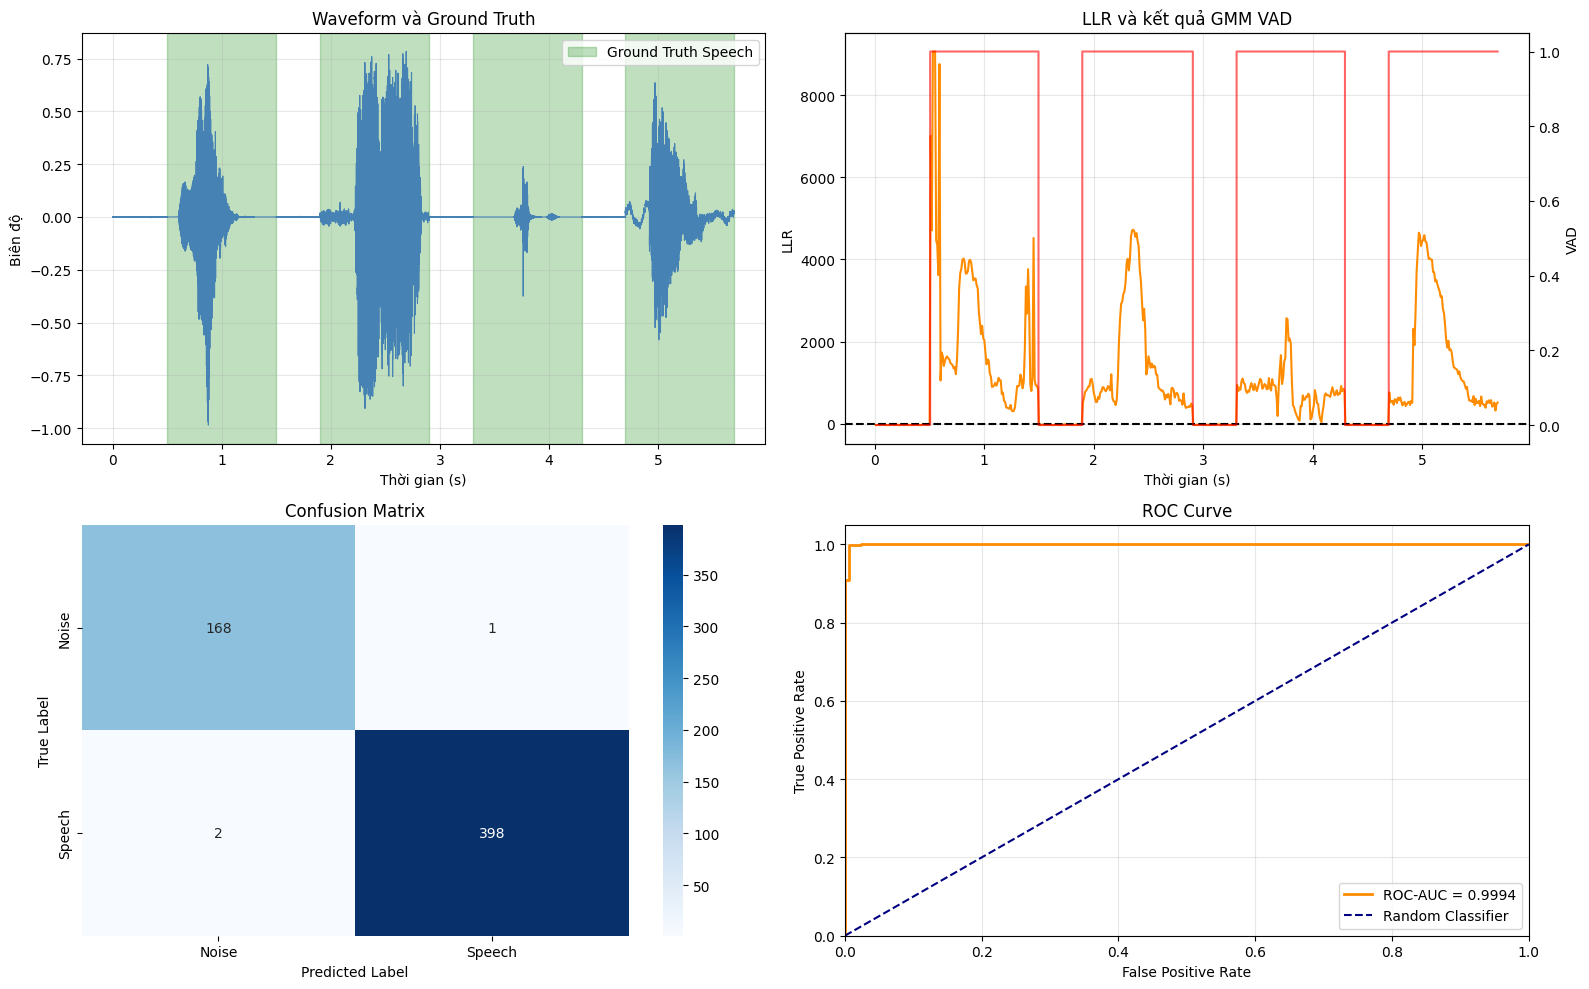

In [ ]:
# TODO 5: Vẽ đồ thị tổng hợp kết quả Waveform VAD, Confusion Matrix và Đường cong ROC Curve

time_axis = np.arange(len(y)) / sr
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Waveform và Ground Truth
axes[0, 0].plot(time_axis, y, color='steelblue', linewidth=0.8)
for start_sec, end_sec in speech_intervals:
    axes[0, 0].axvspan(
        start_sec,
























































































































































































































        eery
        end_sec,
        color='green',
        alpha=0.25,
        label='Ground Truth Speech',
    )
axes[0, 0].set_title('Waveform và Ground Truth')
axes[0, 0].set_xlabel('Thời gian (s)')
axes[0, 0].set_ylabel('Biên độ')
axes[0, 0].grid(alpha=0.3)
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    unique_labels = dict(zip(labels, handles))
    axes[0, 0].legend(unique_labels.values(), unique_labels.keys())

# 2. Kết quả GMM VAD và LLR
axes[0, 1].plot(frame_times, llr, color='darkorange', label='LLR')
axes[0, 1].axhline(
    0.0,
    color='black',
    linestyle='--',
    label='Threshold = 0.0',
)
axes[0, 1].set_title('LLR và kết quả GMM VAD')
axes[0, 1].set_xlabel('Thời gian (s)')
axes[0, 1].set_ylabel('LLR')
axes[0, 1].grid(alpha=0.3)

vad_axis = axes[0, 1].twinx()
vad_axis.step(
    frame_times,
    y_pred,
    where='mid',
    color='red',
    alpha=0.6,
    label='GMM VAD',
)
vad_axis.set_ylabel('VAD')

# 3. Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Noise', 'Speech'],
    yticklabels=['Noise', 'Speech'],
    ax=axes[1, 0],
)
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')

# 4. ROC Curve
axes[1, 1].plot(
    fpr,
    tpr,
    color='darkorange',
    linewidth=2,
    label=f'ROC-AUC = {roc_auc:.4f}',
)
axes[1, 1].plot(
    [0, 1],
    [0, 1],
    color='navy',
    linestyle='--',
    label='Random Classifier',
)
axes[1, 1].set_title('ROC Curve')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_xlim([0, 1])
axes[1, 1].set_ylim([0, 1.05])
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 7. Câu hỏi thảo luận & Mở rộng

**Câu hỏi 1:** Trong lớp `sklearn.mixture.GaussianMixture`, tham số `n_components` ảnh hưởng thế nào đến khả năng biểu diễn phân phối âm thanh của lớp Nhiễu (`gmm_noise`) và lớp Giọng nói (`gmm_speech`)? Tại sao lớp Giọng nói thường cần số lượng component cao hơn ($K=3$) so với lớp Nhiễu nền ($K=2$)?

*Trả lời của sinh viên:*

Tham số `n_components` là số Gaussian thành phần được dùng để xấp xỉ phân phối xác suất của một lớp. Mỗi Gaussian có thể đại diện cho một cụm đặc trưng âm thanh với trung bình và ma trận hiệp phương sai riêng.

Nếu chọn quá ít component, GMM không mô tả được đầy đủ sự đa dạng của dữ liệu. Khi đó mô hình có thể bị underfitting, làm cho log-likelihood của các frame Speech hoặc Noise không chính xác. Ngược lại, nếu chọn quá nhiều component so với lượng dữ liệu, mô hình dễ bị overfitting, học cả nhiễu ngẫu nhiên và tạo ra ma trận hiệp phương sai không ổn định.

Lớp Noise nền thường có phân phối tương đối đơn giản và ổn định, đặc biệt khi nhiễu được tạo gần như Gaussian với biên độ nhỏ. Vì vậy, số component thấp như $K=2$ thường đã đủ để mô tả các biến thiên chính của lớp Noise.

Lớp Speech đa dạng hơn nhiều. Các âm vị, nguyên âm, phụ âm, cao độ, năng lượng và người nói khác nhau tạo ra nhiều vùng phân bố trong không gian đặc trưng. Do đó, lớp Speech thường cần nhiều component hơn, chẳng hạn $K=3$, để mô tả các nhóm đặc trưng khác nhau.

Tuy nhiên, $K=2$ và $K=3$ chỉ là giá trị khởi đầu. Trong thực tế có thể chọn `n_components` bằng validation set, BIC hoặc AIC. Mục tiêu là đạt cân bằng giữa log-likelihood, độ chính xác VAD và độ ổn định khi phát hiện các đoạn Speech mới.


**Câu hỏi 2:** Dựa trên đường cong ROC Curve và các chỉ số Precision/Recall thu được từ `sklearn.metrics`, làm thế nào để điều chỉnh ngưỡng $\tau$ của LLR nhằm tối ưu bài toán VAD cho hệ thống Nhận dạng Giọng nói (Speech Recognition - ASR) so với hệ thống Nén cuộc gọi VoIP?

*Trả lời của sinh viên:*

Ngưỡng $\tau$ quyết định cách chuyển điểm LLR liên tục thành nhãn VAD:

$$
VAD(x) = 1 \quad \text{khi} \quad LLR(x) > \tau
$$

Tăng $\tau$ làm cho bộ phát hiện khó kết luận một frame là Speech hơn. Khi đó False Positive giảm và Precision tăng, nhưng Recall có thể giảm do bỏ sót các đoạn Speech yếu. Giảm $\tau$ có tác dụng ngược lại: Recall tăng nhưng nhiều frame Noise có thể bị nhận nhầm thành Speech.

Đối với hệ thống ASR, việc bỏ sót Speech thường nghiêm trọng vì có thể làm mất âm vị hoặc từ trong câu. Vì vậy nên ưu tiên Recall cao, chấp nhận một mức False Positive vừa phải. Có thể chọn $\tau$ tại điểm trên ROC gần với vùng TPR cao, hoặc tối ưu F1-score với trọng số ưu tiên Recall. Trong thực tế cũng có thể dùng ngưỡng bật thấp hơn và ngưỡng tắt cao hơn để tạo hysteresis, tránh việc VAD bật tắt liên tục.

Đối với hệ thống nén cuộc gọi VoIP, False Positive thường gây lãng phí băng thông và làm giảm hiệu quả Voice Activity Detection. Vì vậy có thể chọn $\tau$ cao hơn để tăng Precision và giảm thời gian truyền Noise. Tuy nhiên, không nên tăng ngưỡng quá mức vì sẽ làm mất các đoạn Speech nhỏ hoặc câu nói có âm lượng thấp.

Cách chọn ngưỡng thực tế là tính Precision, Recall, F1-score và ROC-AUC trên validation set, sau đó chọn điểm phù hợp với chi phí của từng loại lỗi. ASR thường chọn thiên về Recall, còn VoIP thường chọn thiên về Precision và tỷ lệ tiết kiệm băng thông. Ngưỡng cuối cùng nên được kiểm tra thêm trên dữ liệu có nhiều người nói, mức ồn và thiết bị ghi âm khác nhau.